# 우송대학교 컴퓨터정보보안전공 202110716 백지원

## **이원분산분석 예제**

- 문제: 두 가지 요인(고혈압약의 종류, 처방 용량)에 따라 수축기 혈압이 유의하게 차이가 있는지 검정

In [7]:
import pandas as pd

# 예제를 위한 데이터 생성. 2*3*2 요인설계
df = pd.DataFrame({
    'drug': ['A']*6 + ['B']*6,
    'dosage': [100, 100, 150, 150, 200, 200]*2,
    'BP': [184, 168, 160, 145, 192, 176, 143, 167, 135, 123, 140, 152]
})

# 처리 열 추가
df['treatment'] = df['drug'] + '-' + df['dosage'].astype(str)

df

,drug,dosage,BP,treatment
0,A,100,184,A-100
1,A,100,168,A-100
2,A,150,160,A-150
3,A,150,145,A-150
4,A,200,192,A-200
5,A,200,176,A-200
6,B,100,143,B-100
7,B,100,167,B-100
8,B,150,135,B-150
9,B,150,123,B-150


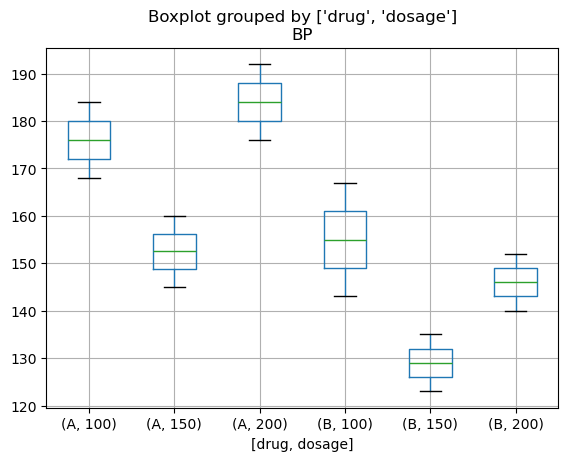

In [8]:
# 박스 플롯으로 시각화
df.boxplot(by=['drug', 'dosage']);

### 2. 가정 확인

- 정규성 검정은 편의상 전체 데이터를 사용하여 수행

통계량: 0.9771, p-value: 0.9692
정규분포를 따름


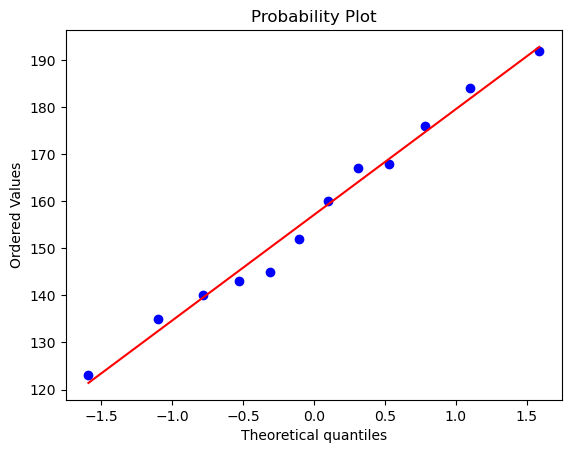

In [9]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Shapiro-Wilk 검정
stat, p_value = stats.shapiro(df.BP)
print(f'통계량: {stat:.4f}, p-value: {p_value:.4f}')
if p_value < 0.05:
    print('정규분포를 따르지 않음')
else:
    print('정규분포를 따름')

# Q-Q 플롯
stats.probplot(df.BP, dist="norm", plot=plt)
plt.show()


- 등분산성 검정은 표본이 작으므로 Levene's test를 사용하여 고혈압약 종류 요인에 대해서만 수행

In [10]:
# Levene 검정
stat, p_value = stats.levene(df.BP[df.drug=='A'], df.BP[df.drug=='B'])
print(f'통계량: {stat:.4f}, p-value: {p_value:.4f}')
if p_value < 0.05:
    print('모든 그룹의 분산이 같지 않음')
else:
    print('모든 그룹의 분산이 같음')


통계량: 0.2141, p-value: 0.6535
모든 그룹의 분산이 같음


### 3. ANOVA Table 작성

In [11]:
# 회귀분석을 위한 ols 함수와 anova_lm 함수 임포트
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# 분산분석 모형을 formula 형태로 만들기. C() 함수는 범주형 변수임을 나타냄
formula = 'BP ~ C(drug) + C(dosage) + C(drug):C(dosage)'

# 분산분석 모형 생성 및 적합
model = ols(formula, df).fit()

# 분산분석 결과표 출력
result = anova_lm(model)
print(result)


                    df       sum_sq      mean_sq          F    PR(>F)
C(drug)            1.0  2268.750000  2268.750000  17.004997  0.006190
C(dosage)          2.0  1601.166667   800.583333   6.000625  0.037029
C(drug):C(dosage)  2.0   168.500000    84.250000   0.631480  0.563784
Residual           6.0   800.500000   133.416667        NaN       NaN


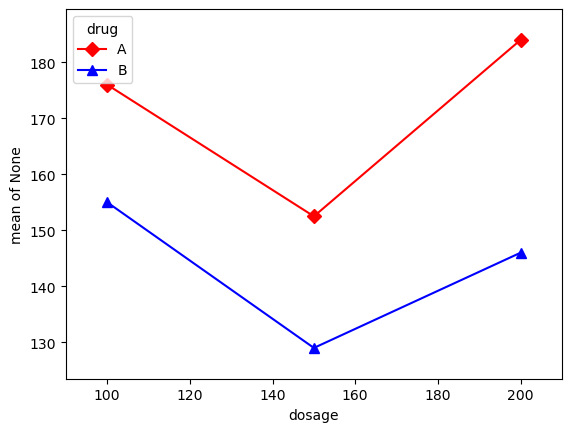

In [12]:
# 교호작용도 그래프 그리기
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt

fig = interaction_plot(
    x = df['dosage'],         # x축 변수
    trace = df['drug'],       # 교호작용을 본 변수 (범례)
    response = model.fittedvalues,  # y축 값 (예측값)
    colors = ['red', 'blue'],       # 색상 지정
    markers = ['D', '^'],           # 마커 지정
    ms = 7                          # 마커 크기
)

plt.show()


### 4. 가설검정

- **교호작용효과** `C(drug):C(dosage)`의 p-value가 유의수준 0.05보다 크므로  
  → **연구가설 기각**  
  → **고혈압약의 종류와 복용량의 수준 조합에 따른 차이는 없음**

- **교호작용효과 가설이 기각되었으므로**, 교호작용을 풀링한 후 주효과에 대한 가설 검정 수행
  - 일반적으로 **교호작용효과를 풀링하면 주효과에 대한 p-value가 감소**  
    → **주효과에 대한 연구가설 채택 가능성 증가**


In [13]:
# 교호작용효과를 풀링한 모형
formula = 'BP ~ C(drug) + C(dosage)'

# 분산분석 모형 생성 및 적합
model = ols(formula, df).fit()

# 분산분석 결과표 출력
result = anova_lm(model)
print(result)

            df       sum_sq      mean_sq          F    PR(>F)
C(drug)    1.0  2268.750000  2268.750000  18.730650  0.002519
C(dosage)  2.0  1601.166667   800.583333   6.609563  0.020205
Residual   8.0   969.000000   121.125000        NaN       NaN


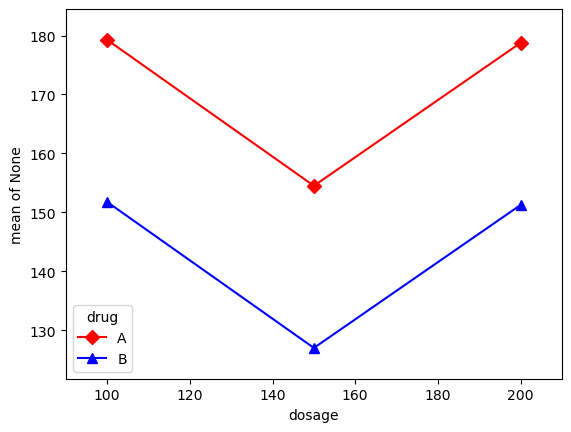

In [14]:
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt

# 교호작용도 그래프 그리기
fig = interaction_plot(
    x = df['dosage'],                 # x축 변수
    trace = df['drug'],              # 교호작용을 볼 변수
    response = model.fittedvalues,   # y축 값 (회귀 예측값)
    colors = ['red', 'blue'],        # 색상 지정
    markers = ['D', '^'],            # 마커 모양
    ms = 7                           # 마커 크기
)

plt.show()


### 5. 사후검정

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper  reject
------------------------------------------------------
 A-100  A-150    -23.5 0.4196  -69.4697 22.4697  False
 A-100  A-200      8.0 0.9762  -37.9697 53.9697  False
 A-100  B-100    -21.0 0.5174  -66.9697 24.9697  False
 A-100  B-150    -47.0 0.0455  -92.9697 -1.0303   True
 A-100  B-200    -30.0   0.23  -75.9697 15.9697  False
 A-150  A-200     31.5  0.199  -14.4697 77.4697  False
 A-150  B-100      2.5 0.9999  -43.4697 48.4697  False
 A-150  B-150    -23.5 0.4196  -69.4697 22.4697  False
 A-150  B-200     -6.5 0.9902  -52.4697 39.4697  False
 A-200  B-100    -29.0 0.2531  -74.9697 16.9697  False
 A-200  B-150    -55.0 0.0226 -100.9697 -9.0303   True
 A-200  B-200    -38.0  0.106  -83.9697  7.9697  False
 B-100  B-150    -26.0 0.3353  -71.9697 19.9697  False
 B-100  B-200     -9.0 0.9616  -54.9697 36.9697  False
 B-150  B-200     17.0 0.6917  -28.9697 62.9697  False
----------

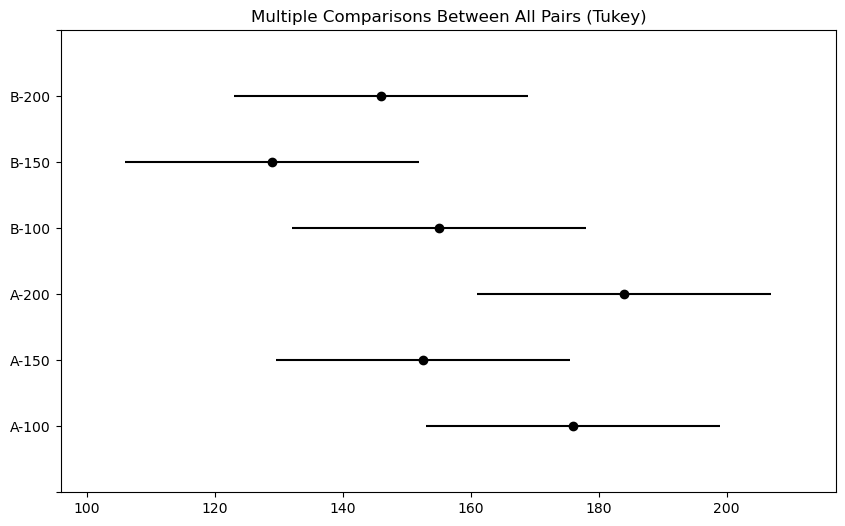

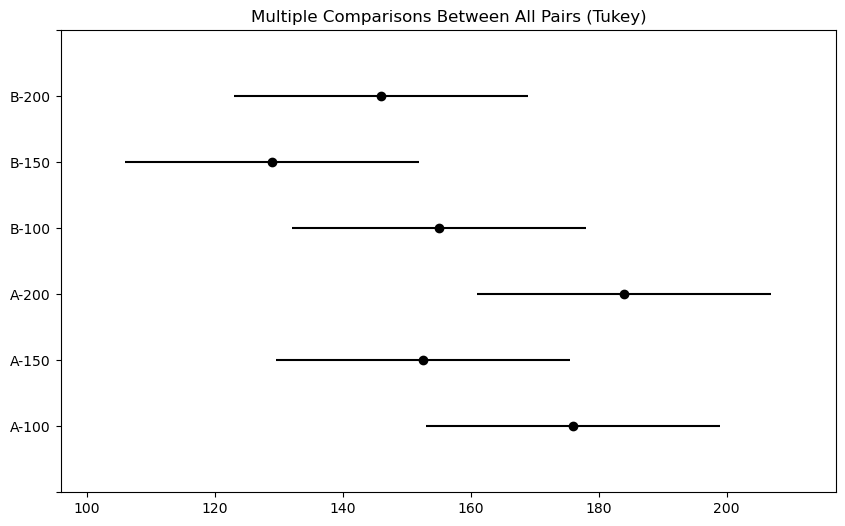

In [15]:
# 사후검정을 위한 모듈 임포트
from statsmodels.stats.multicomp import MultiComparison

# 사후검정 객체 생성 - 특성치는 'BP', 그룹구분은 'treatment'
posthoc = MultiComparison(
    data = df['BP'],
    groups = df['treatment']
)

# 사후검정 방법 적용. Tukey HSD 방법 사용
result = posthoc.tukeyhsd(alpha=0.05)

# 사후검정 결과 요약 출력
print(result.summary())

# 사후검정 결과 시각화
result.plot_simultaneous()


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper  reject
----------------------------------------------------
     A      B    -27.5 0.014 -48.1235 -6.8765   True
----------------------------------------------------


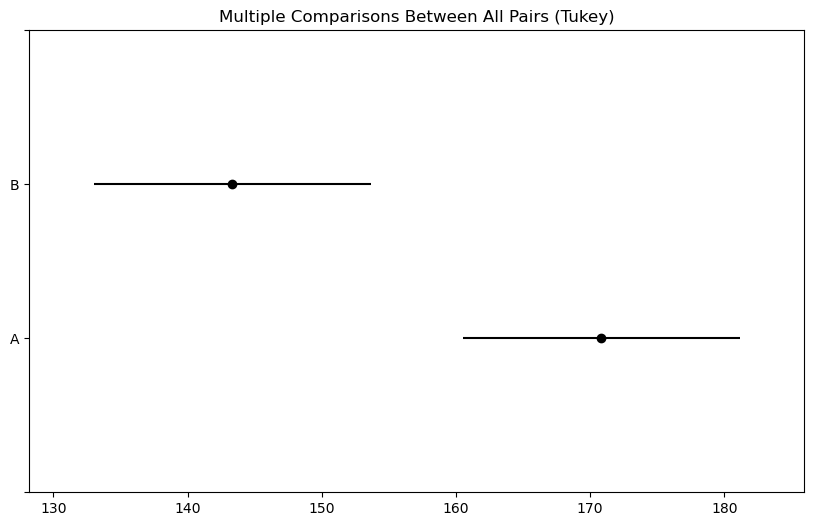

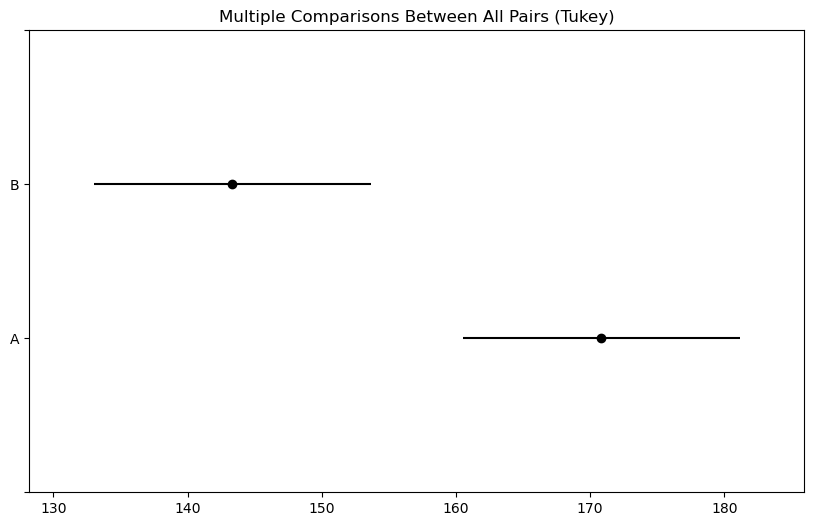

In [16]:
from statsmodels.stats.multicomp import MultiComparison

# 사후검정 객체 생성 - 특성치는 'BP', 그룹구분은 'drug'
posthoc = MultiComparison(
    data = df['BP'],
    groups = df['drug']
)

# 사후검정 방법 적용. Tukey HSD 방법 사용
result = posthoc.tukeyhsd(alpha=0.05)

# 사후검정 결과 요약 출력
print(result.summary())

# 사후검정 결과 시각화
result.plot_simultaneous()


## 응용 코드

### 1. 약 종류에 따른 혈압 차이 비교 (Tukey HSD)

In [17]:
from statsmodels.stats.multicomp import MultiComparison
import pandas as pd

df = pd.DataFrame({
    'BP': [120, 122, 118, 135, 138, 140],  # 혈압 측정값
    'drug': ['A', 'A', 'A', 'B', 'B', 'B']  # 복용한 약 종류
})

result = MultiComparison(df['BP'], df['drug']).tukeyhsd()
print(result.summary())


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B  17.6667 0.0007 12.5138 22.8195   True
----------------------------------------------------


### 2. 두 약물 그룹의 혈압 분산 비교 (Levene Test)

In [20]:
from scipy.stats import levene
import pandas as pd

df = pd.DataFrame({
    'BP': [120, 122, 118, 135, 138, 140],   # 수축기 혈압
    'drug': ['A', 'A', 'A', 'B', 'B', 'B']  # 복용한 약 종류
})

stat, p = levene(df.BP[df.drug == 'A'], df.BP[df.drug == 'B'])
print(f'Levene 통계량: {stat:.2f}, p-value: {p:.4f}')

if p < 0.05:
    print(" 두 약 그룹의 혈압 분산이 다릅니다.")
else:
    print(" -> 두 약 그룹의 혈압 분산은 같습니다.")


Levene 통계량: 0.09, p-value: 0.7780
 -> 두 약 그룹의 혈압 분산은 같습니다.
